Nesse notebook, vou aplicar os exercícios e instalações do CS224W

In [2]:
import networkx as nx

# Graph
NetworkX tem várias classes para armazenar diferentes tipos de grafos:

In [3]:
# Cria um undirected graph G
G = nx.Graph()
print(G.is_directed())

# Cria um directed graph H
H = nx.DiGraph()
print(H.is_directed())

# Adiciona atributos à nível grafo
G.graph['Name'] = 'Bar'
print(G.graph)

False
True
{'Name': 'Bar'}


# Node
nodes (com atributos) conseguem ser facilmente adicionados

In [5]:
# adiciona um node com atributos à node level
G.add_node(0, feature=5, label=1)

# Pega os atributos do node 0
node_0_att = G.nodes[0]
print("Node 0 tem os atributos {}".format(node_0_att))

Node 0 tem os atributos {'feature': 5, 'label': 1}


In [8]:
G.nodes(data=True)

NodeDataView({0: {'feature': 5, 'label': 1}, 1: {'feature': 1, 'label': 1}, 2: {'feature': 2, 'label': 2}})

In [9]:
# adiciona multiplos nodes com atributos
G.add_nodes_from([
    (1, {'feature': 1, 'label': 1}),
    (2, {'feature': 2, 'label': 2})
])

#Seta data=True para todos os nodes, retornando os atributos
for node in G.nodes(data=True):
    print(node)

# Pega o número de nodes
num_nodes = G.number_of_nodes()
print('G tem {} nodes'.format(num_nodes))

(0, {'feature': 5, 'label': 1})
(1, {'feature': 1, 'label': 1})
(2, {'feature': 2, 'label': 2})
G tem 3 nodes


# Edge
Similar a nodes, edges (com atrivutos) podem ser facilmente adicionados

In [10]:
# adiciona uma edge com peso 0.5
G.add_edge(0, 1, weight=.5)

# pega os atributos do edge (0, 1)
edge_0_1_att = G.edges[(0, 1)]
print('Edge (0, 1) tem os atributos {}'.format(edge_0_1_att))

Edge (0, 1) tem os atributos {'weight': 0.5}


In [12]:
# adiciona multiplos edges com atributos
G.add_edges_from([
    (1, 2, {'weight': 0.3}),
    (2, 0, {'weight': 0.1})
])

for edge in G.edges():
    print(edge)

num_edges = G.number_of_edges()
print("G has {} edges".format(num_edges))

(0, 1)
(0, 2)
(1, 2)
G has 3 edges


# Visualização

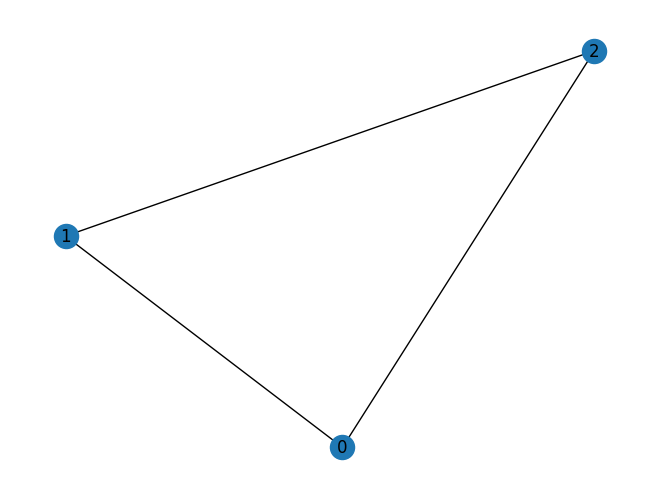

In [13]:
nx.draw(G, with_labels=True)

# Node degree e Neighbor

In [14]:
node_id = 1

# Degree do node 1
print('Node {} tem o grau {}'.format(node_id, G.degree[node_id]))

# Pega o neighbor do node 1
for x in G.neighbors(node_id):
    print('Node {} tem o neighbor {}'.format(node_id, x))

Node 1 tem o grau 2
Node 1 tem o neighbor 0
Node 1 tem o neighbor 2


# Outras funcionalidades
NX também tem vários métodos para estudo de grafos, a seguir um exemplo de como pegar o PageRank dos nodes.

O PageRank calcula uma classificação (ranking) dos nós em um grafo $G$ com base na estrutura dos links de entrada. Ele foi originalmente projetado como um algoritmo para classificar páginas da web.

In [15]:
nx.path_graph(num_nodes)

{0: 0.17857162031103999,
 1: 0.32142837968896,
 2: 0.32142837968896,
 3: 0.17857162031103999}

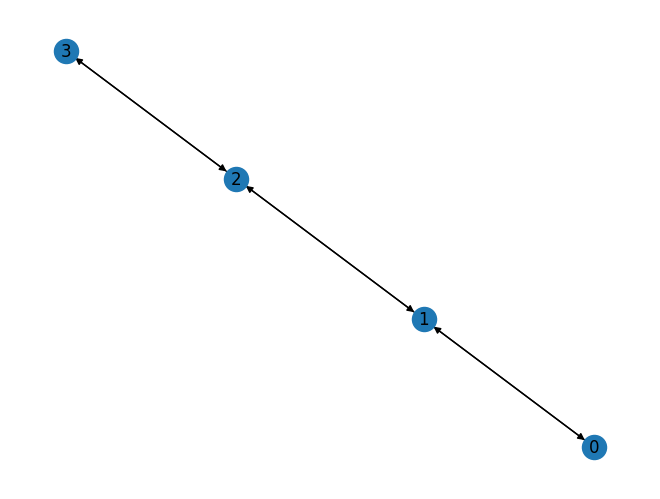

In [16]:
num_nodes = 4
G = nx.DiGraph(nx.path_graph(num_nodes))
nx.draw(G, with_labels = True)

# Pega o PageRank
pr = nx.pagerank(G, alpha=0.8)
pr

# PyTorch Geometric
Extensão do PyTorch, realiza GNNs

In [19]:
import torch

# Visualização

In [20]:
# função auxiliar pra visualização
%matplotlib inline
import torch
import networkx as nx
import matplotlib.pyplot as plt

def visualize(h, color, epoch=None, loss=None, accuracy=None):
    plt.figure(figsize=(7,7))
    plt.xticks([])
    plt.yticks([])

    if torch.is_tensor(h):
        h = h.detach().cpu().numpy()
        plt.scatter(h[:, 0], h[:, 1], s=140, c=color, cmap="Set2")
        if epoch is not None and loss is not None and accuracy['train'] is not None and accuracy['val'] is not None:
            plt.xlabel((f'Epoch: {epoch}, Loss: {loss.item():.4f} \n'
                       f'Training Accuracy: {accuracy["train"]*100:.2f}% \n'
                       f' Validation Accuracy: {accuracy["val"]*100:.2f}%'),
                       fontsize=16)
    else:
        nx.draw_networkx(h, pos=nx.spring_layout(h, seed=42), with_labels=False,
                         node_color=color, cmap="Set2")
    plt.show()

# Introdução
Graph Neural Networks (GNNs) têm como objetivo generalizar conceitos clássicos de deep learning para dados com estrutura irregular (em contraste com imagens ou textos) e permitir que redes neurais raciocinem sobre objetos e suas relações.

In [21]:
# utilizaremos o KarateClub data set
from torch_geometric.datasets import KarateClub

dataset = KarateClub()
print(f'Dataset: {dataset}:')
print('======================')
print(f'Grafos: {len(dataset)}')
print(f'Features: {dataset.num_features}')
print(f'Classes: {dataset.num_classes}')

/Users/felipetomepereira/Projects/homl-deep-learning-ensemble-unsupervised/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset: KarateClub():
Grafos: 1
Features: 34
Classes: 4


depois de inicializarmos o dataset, podemos primeiro inspecionar algumas propriedades. Por exemplo, podemos ver que o dataset tem exatamente 1 grafo, e que cada node no dataset está assimilado a vetor de características de 34 dimensões (que descreve de forma única os membros do clube de karatê). Além do mais, o grafo contém exatamente 4 classes, que represetnam as comunidades cada node pertence

In [24]:
data = dataset[0] # pega o grafo

print(data)


# aqui é importante saber algumas estatísticas sobre o grafo
print(f'nodes: {data.num_nodes}')
print(f'edges: {data.num_edges}')
print(f'Grau médio de nodes: {(data.num_edges) / data.num_nodes:.2f}')
print(f'training nodes: {data.train_mask.sum()}')
print(f'Taxa de label do trainin node: {int(data.train_mask.sum()) / data.num_nodes:.2f}')
print(f'COntém nodes isolados: {data.has_isolated_nodes()}')
print(f'Contém self-loops: {data.has_self_loops()}')
print(f'É undirected: {data.is_undirected()}')

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])
nodes: 34
edges: 156
Grau médio de nodes: 4.59
training nodes: 4
Taxa de label do trainin node: 0.12
COntém nodes isolados: False
Contém self-loops: False
É undirected: True


# Dados
Cada grafo no PyTorch Geometric é representado por um único objeto Data, que contém todas as informações necessárias para descrever sua representação em grafo. Podemos imprimir o objeto `data` a qualquer momento usando `print(data)` para obter um breve resumo de seus atributos e de seus respectivos formatos (shapes).

In [25]:
print(data)

Data(x=[34, 34], edge_index=[2, 156], y=[34], train_mask=[34])


Podemos ver que esse objeto data possui 4 atributos:

1. A propriedade edge_index contém as informações sobre a conectividade do grafo, ou seja, uma tupla com os índices do nó de origem e do nó de destino para cada aresta.
2. O PyG se refere às features dos nós como x (cada um dos 34 nós possui um vetor de características de 34 dimensões).
3. Os rótulos dos nós são representados por y (cada nó pertence exatamente a uma classe).
4. Existe também um atributo adicional chamado train_mask, que indica para quais nós já conhecemos suas atribuições de comunidade.

No total, conhecemos os rótulos verdadeiros de apenas 4 nós (um para cada comunidade), e a tarefa é inferir a comunidade dos nós restantes.

In [26]:
edge_index = data.edge_index
print(edge_index.t())

tensor([[ 0,  1],
        [ 0,  2],
        [ 0,  3],
        [ 0,  4],
        [ 0,  5],
        [ 0,  6],
        [ 0,  7],
        [ 0,  8],
        [ 0, 10],
        [ 0, 11],
        [ 0, 12],
        [ 0, 13],
        [ 0, 17],
        [ 0, 19],
        [ 0, 21],
        [ 0, 31],
        [ 1,  0],
        [ 1,  2],
        [ 1,  3],
        [ 1,  7],
        [ 1, 13],
        [ 1, 17],
        [ 1, 19],
        [ 1, 21],
        [ 1, 30],
        [ 2,  0],
        [ 2,  1],
        [ 2,  3],
        [ 2,  7],
        [ 2,  8],
        [ 2,  9],
        [ 2, 13],
        [ 2, 27],
        [ 2, 28],
        [ 2, 32],
        [ 3,  0],
        [ 3,  1],
        [ 3,  2],
        [ 3,  7],
        [ 3, 12],
        [ 3, 13],
        [ 4,  0],
        [ 4,  6],
        [ 4, 10],
        [ 5,  0],
        [ 5,  6],
        [ 5, 10],
        [ 5, 16],
        [ 6,  0],
        [ 6,  4],
        [ 6,  5],
        [ 6, 16],
        [ 7,  0],
        [ 7,  1],
        [ 7,  2],
        [ 

Ao imprimir edge_index, podemos entender melhor como o PyG representa internamente a conectividade do grafo. Podemos ver que, para cada aresta, edge_index contém uma tupla com dois índices de nós, onde o primeiro valor descreve o índice do nó de origem e o segundo valor descreve o índice do nó de destino de uma aresta.

Essa representação é conhecida como formato COO (Coordinate Format), comumente utilizado para representar matrizes esparsas.

Também podemos visualizar melhor o grafo convertendo-o para o formato da biblioteca NetworkX, que além de oferecer funcionalidades para manipulação de grafos, também possui ferramentas poderosas de visualização.

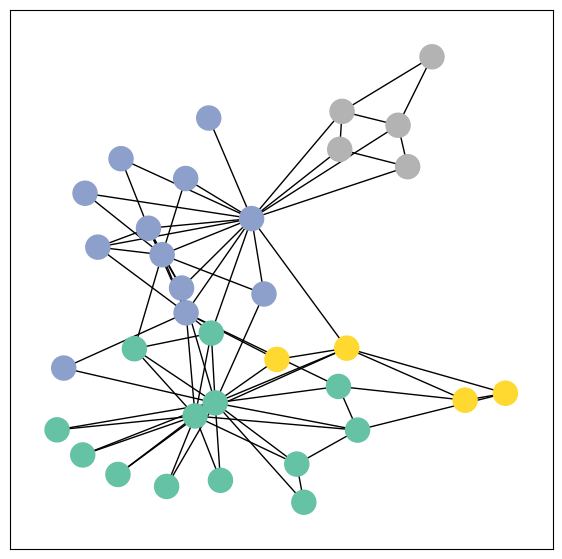

In [27]:
from torch_geometric.utils import to_networkx

G = to_networkx(data, to_undirected=True)
visualize(G, color=data.y)

# Implementando GNNS

In [28]:
from torch.nn import Linear
from torch_geometric.nn import GCNConv

class GCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        torch.manual_seed(1234)
        self.conv1 = GCNConv(dataset.num_features, 4)
        self.conv2 = GCNConv(4, 4)
        self.conv3 = GCNConv(4, 2)
        self.classifier = Linear(2, dataset.num_classes)

    def forward(self, x, edge_index):
        h = self.conv1(x, edge_index)
        h = h.tanh()
        h = self.conv2(h, edge_index)
        h = h.tanh()
        h = self.conv3(h, edge_index)
        h = h.tanh()  # Final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(h)

        return out, h

model = GCN()
print(model)

GCN(
  (conv1): GCNConv(34, 4)
  (conv2): GCNConv(4, 4)
  (conv3): GCNConv(4, 2)
  (classifier): Linear(in_features=2, out_features=4, bias=True)
)


Embedding shape: [34, 2]


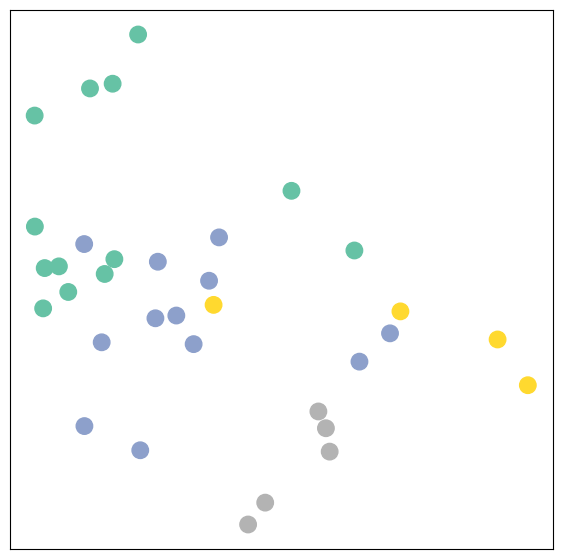

In [29]:
model = GCN()

_, h = model(data.x, data.edge_index)
print(f'Embedding shape: {list(h.shape)}')

visualize(h, color=data.y)

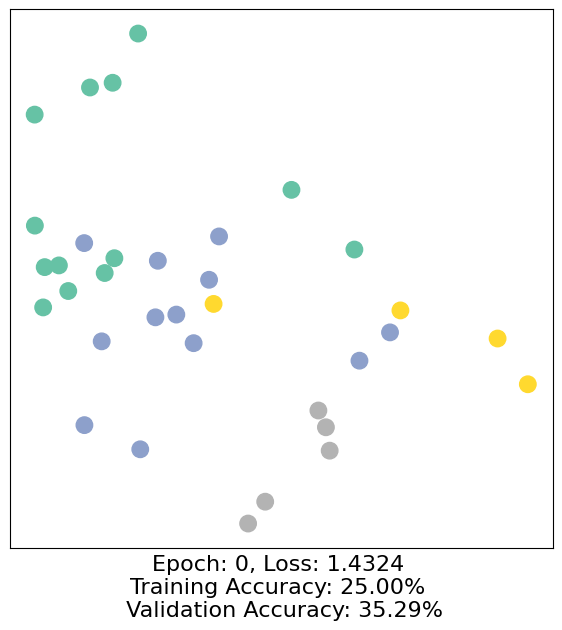

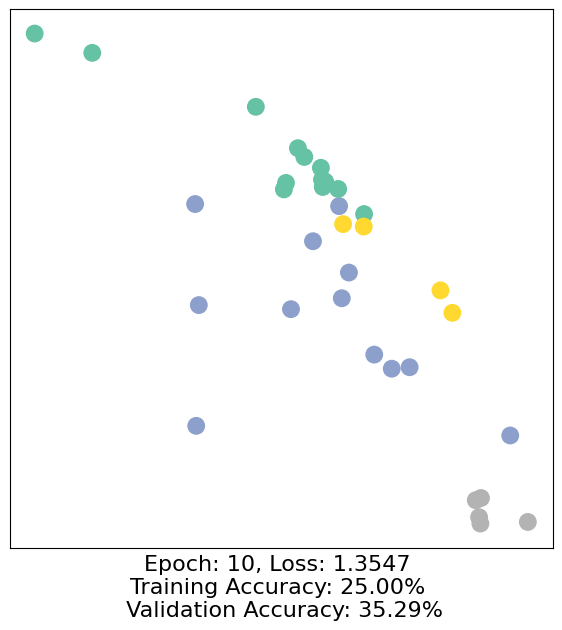

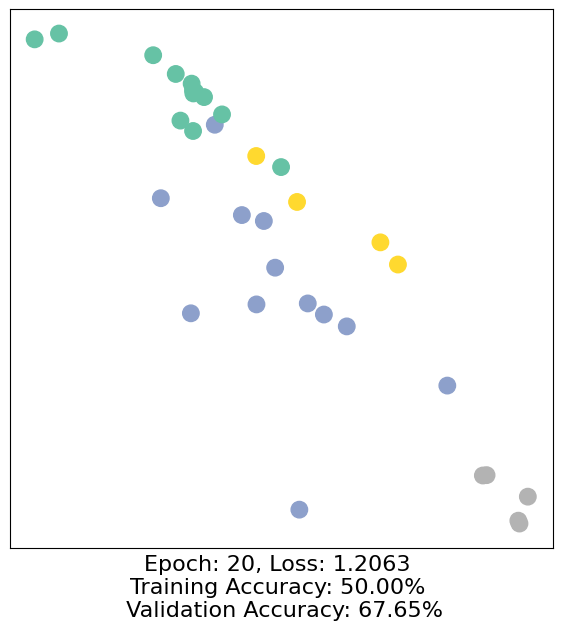

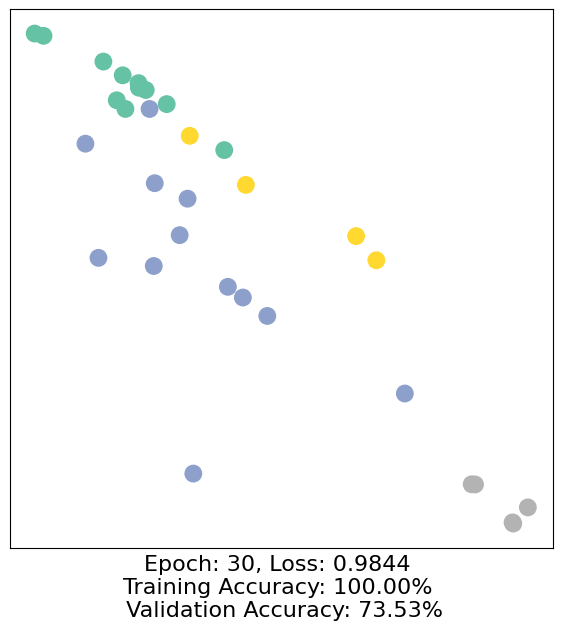

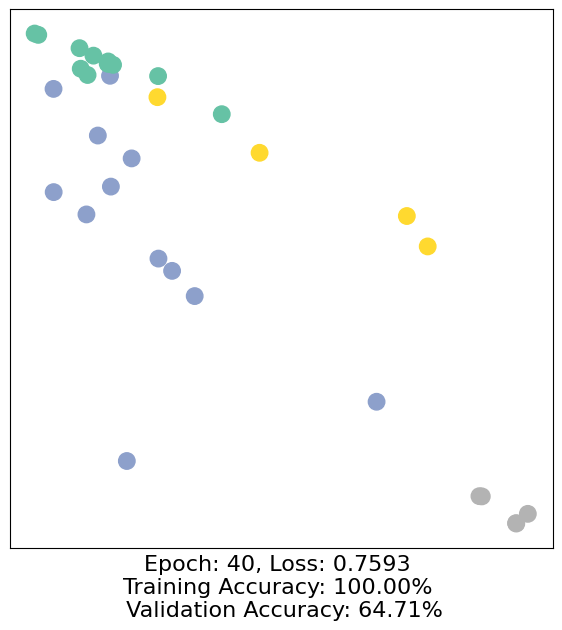

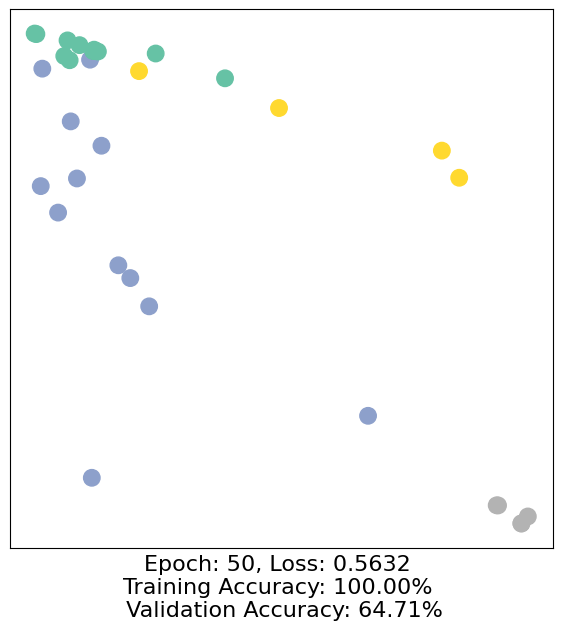

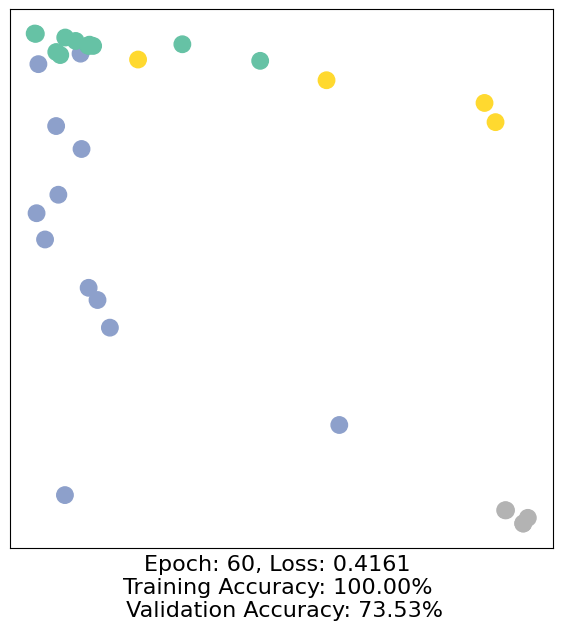

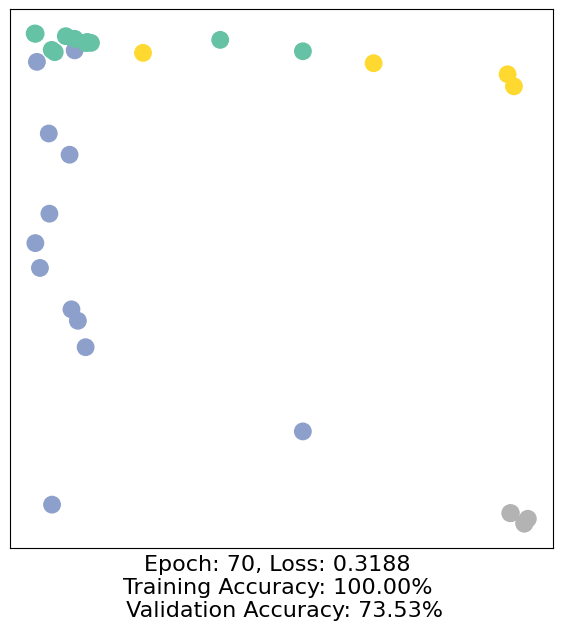

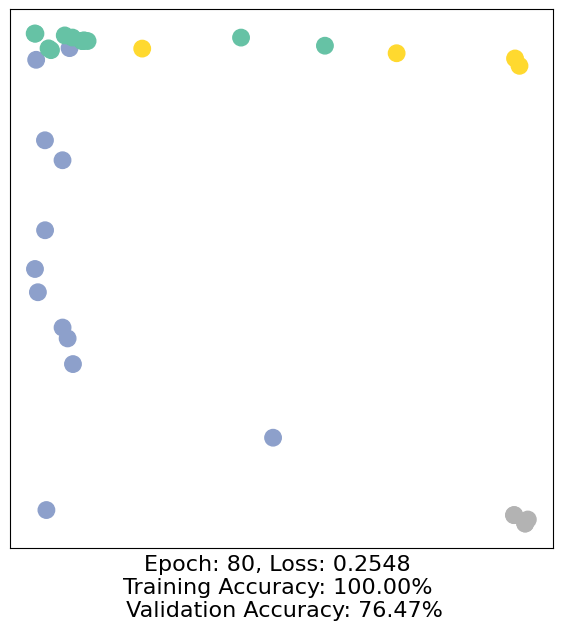

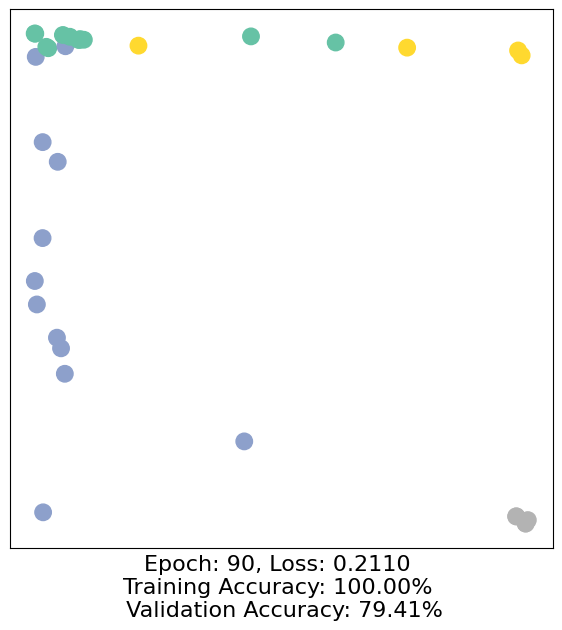

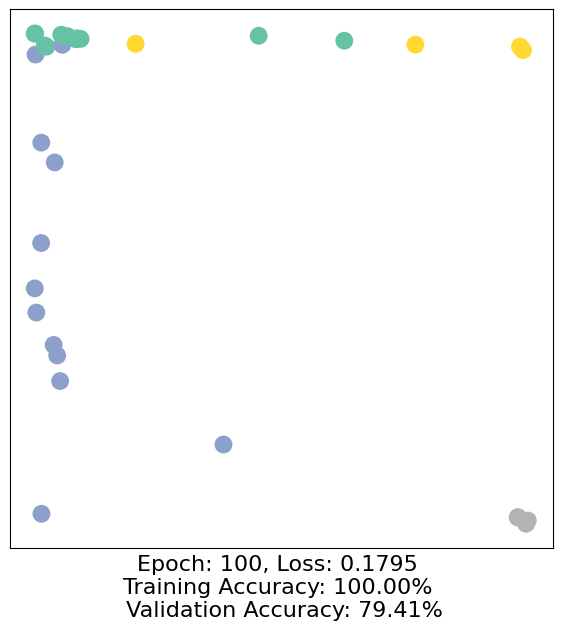

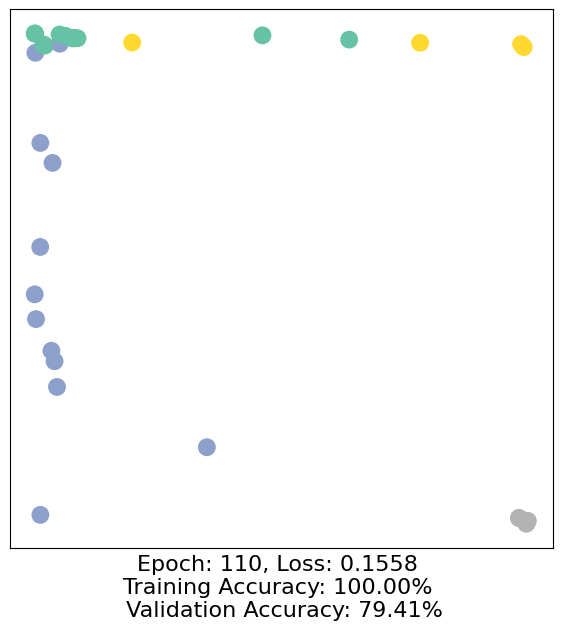

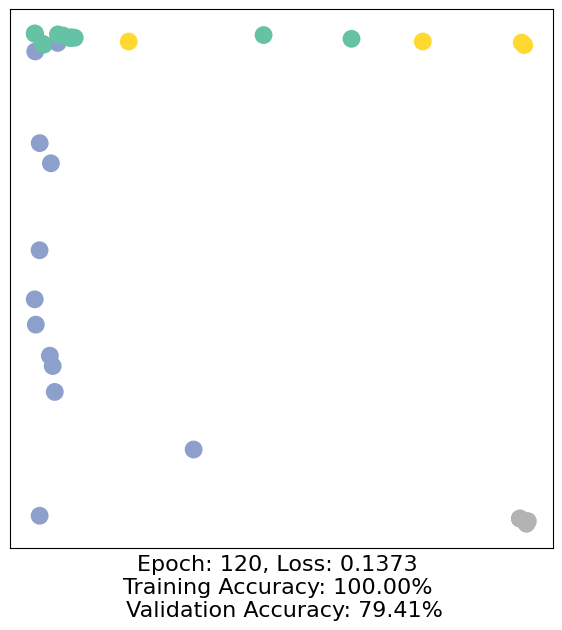

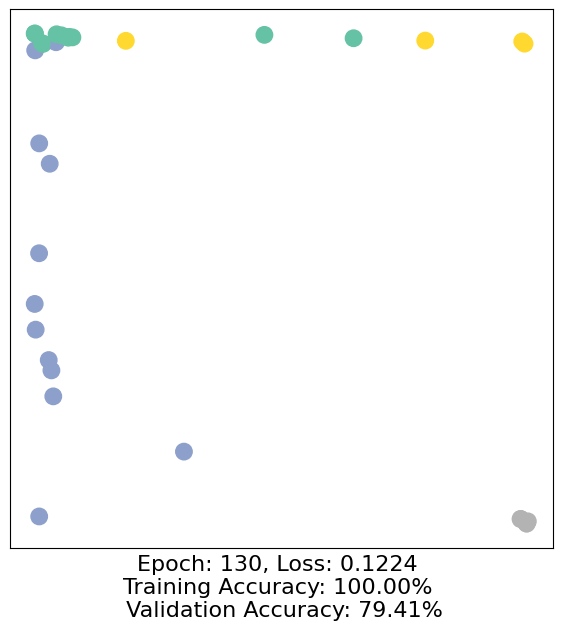

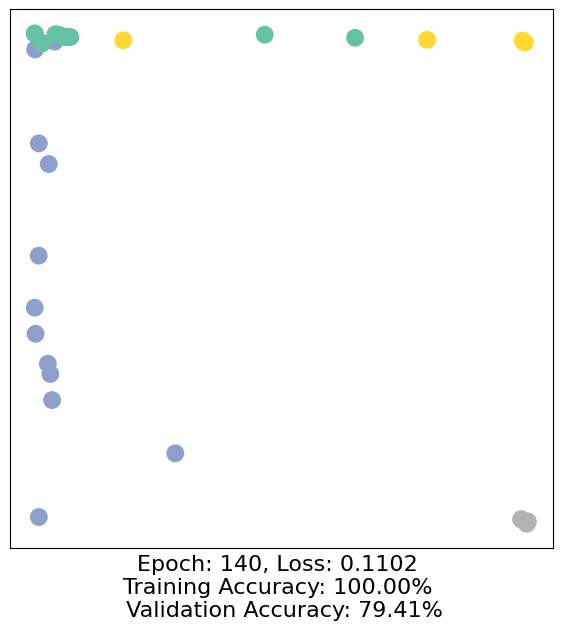

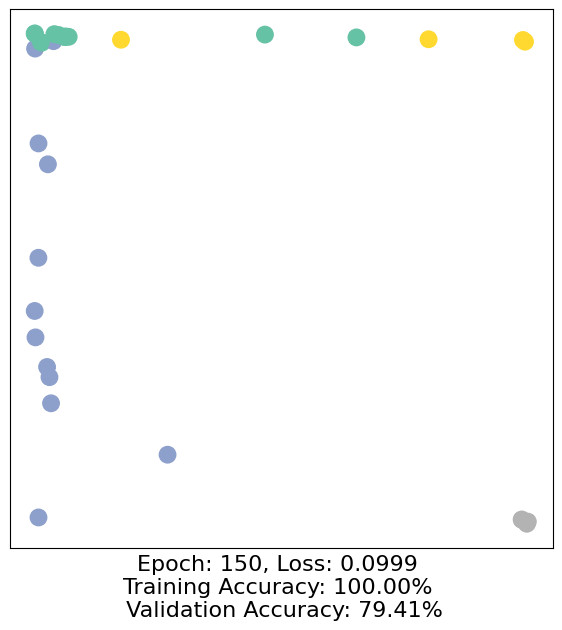

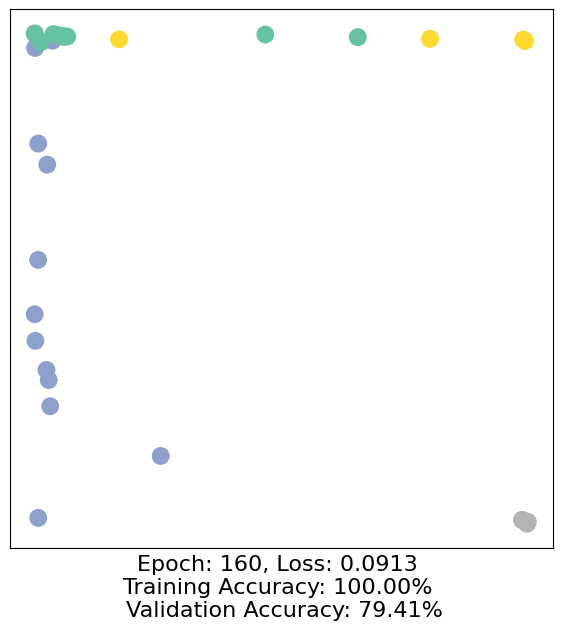

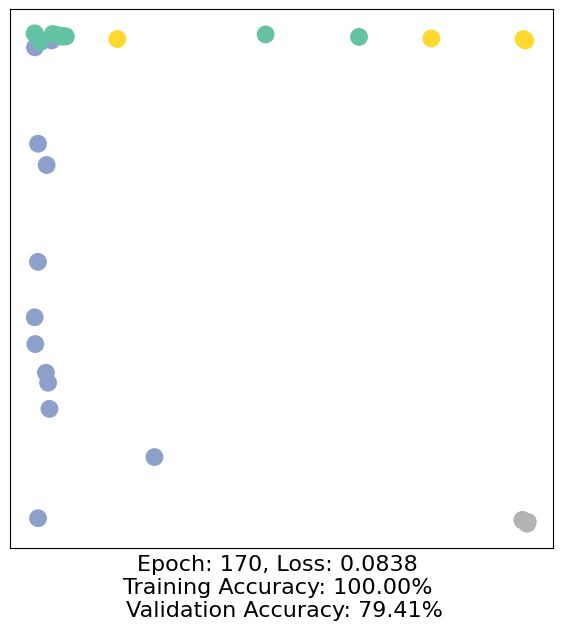

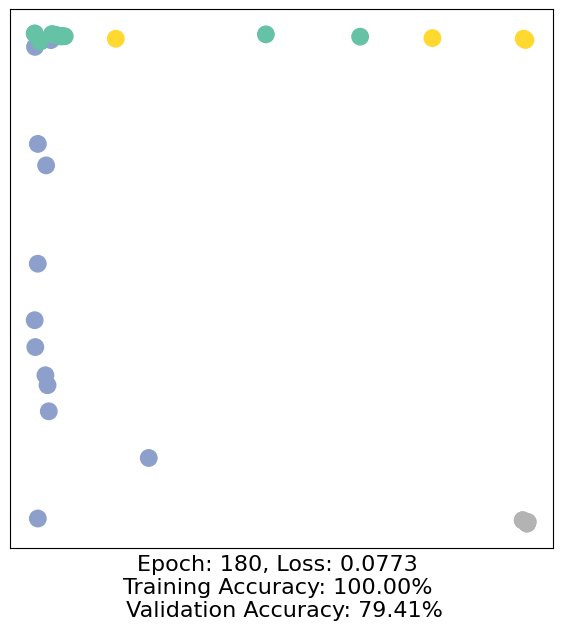

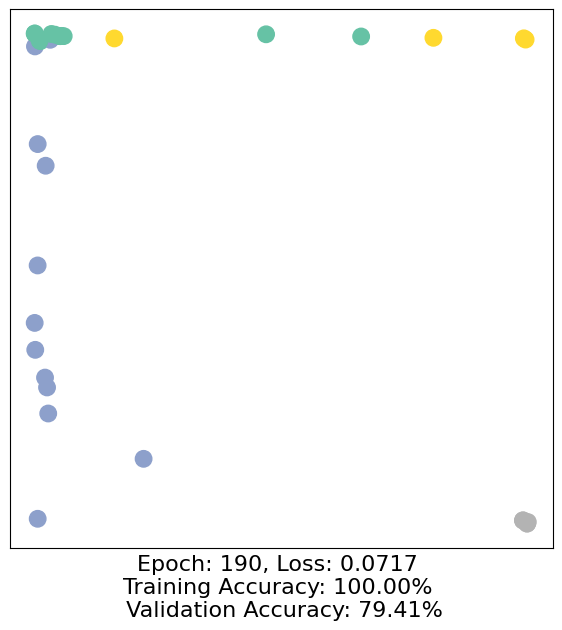

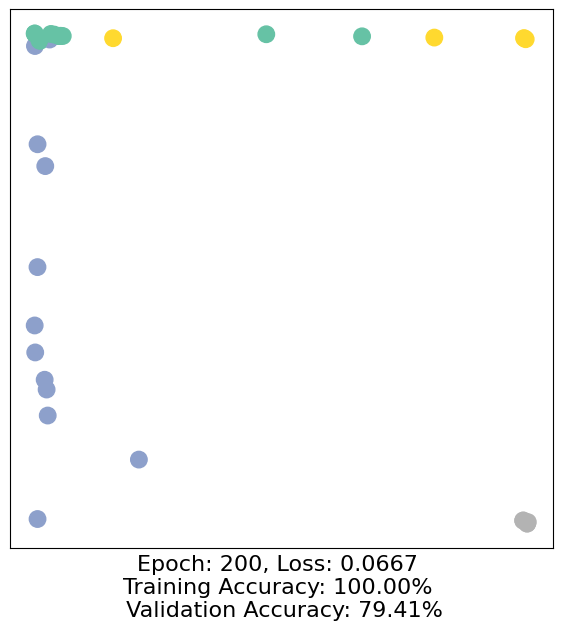

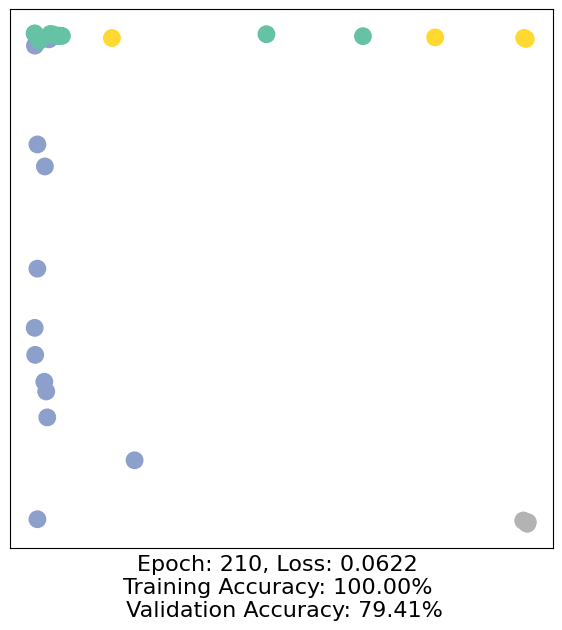

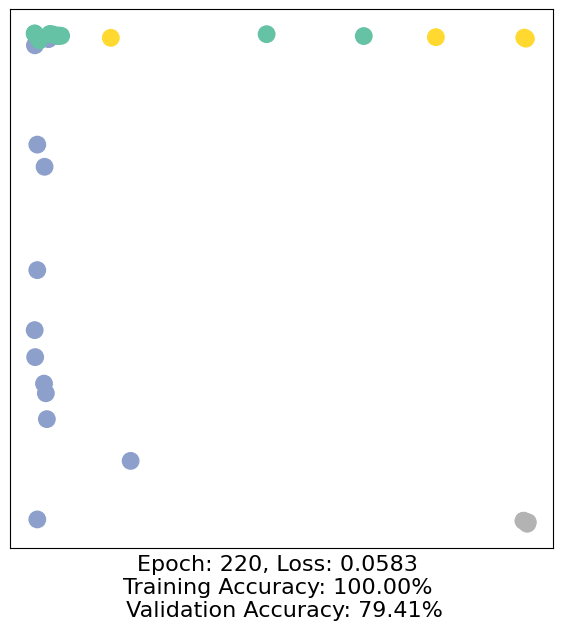

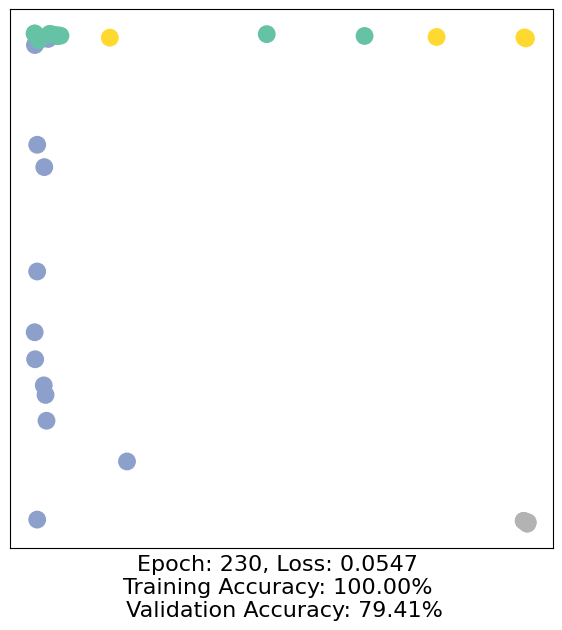

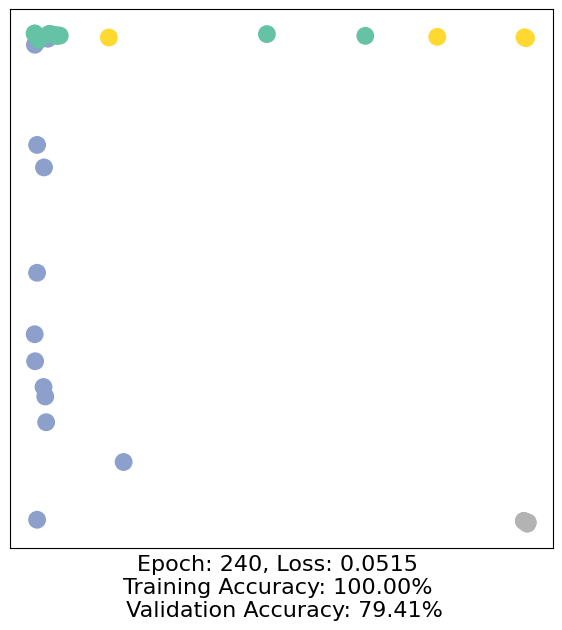

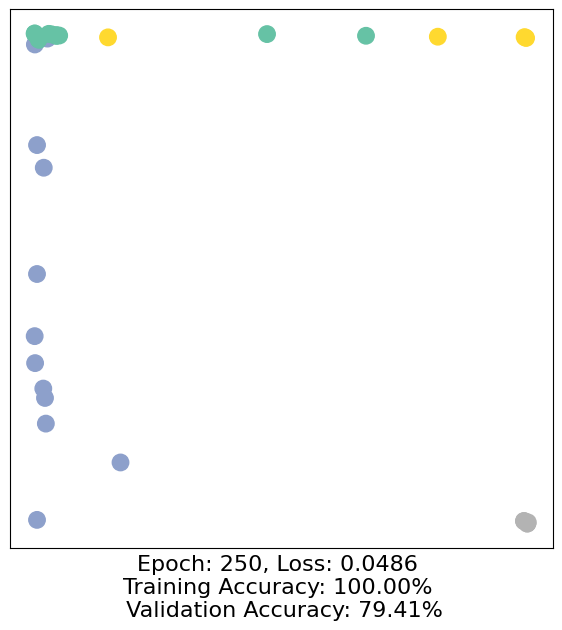

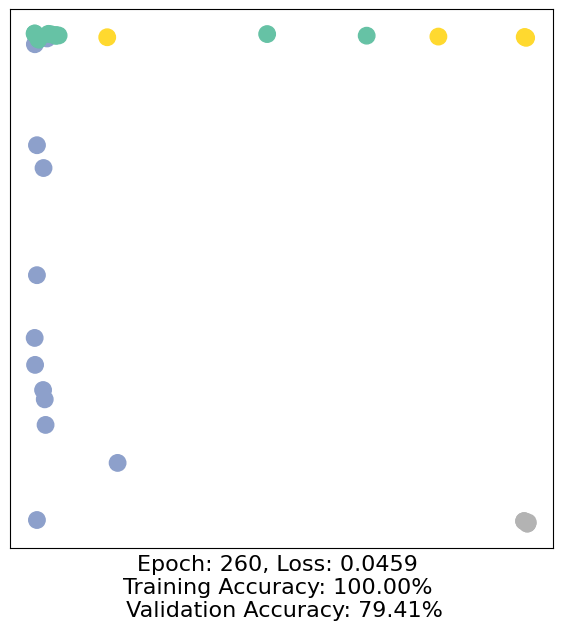

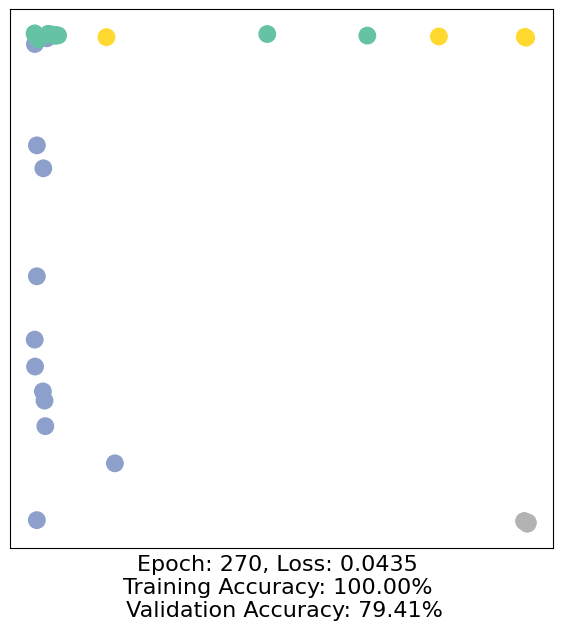

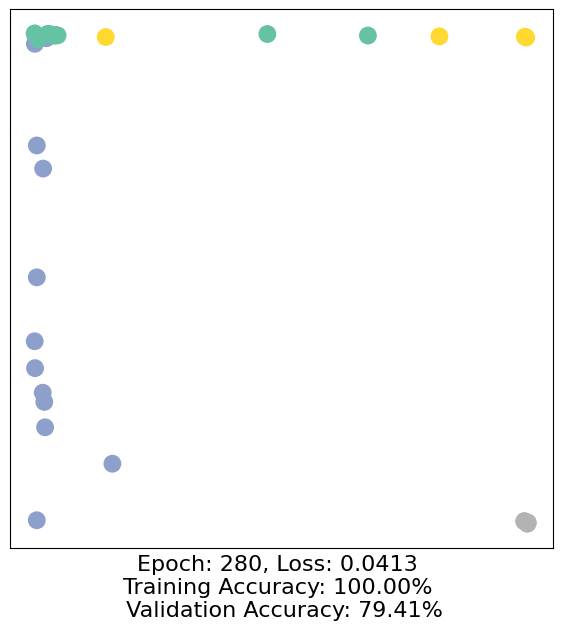

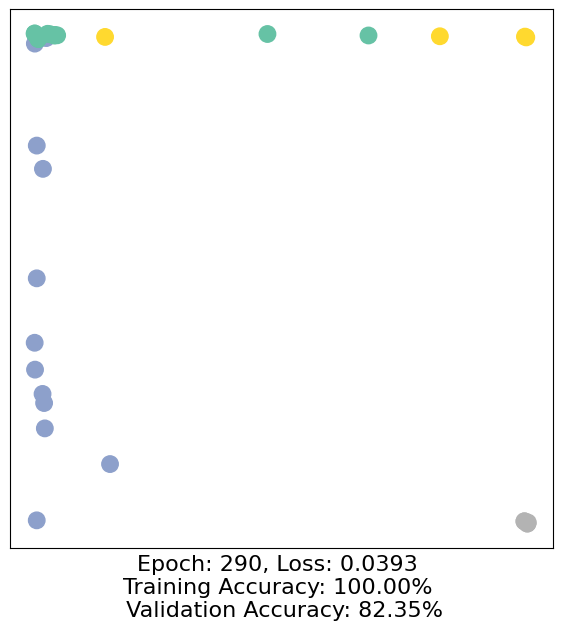

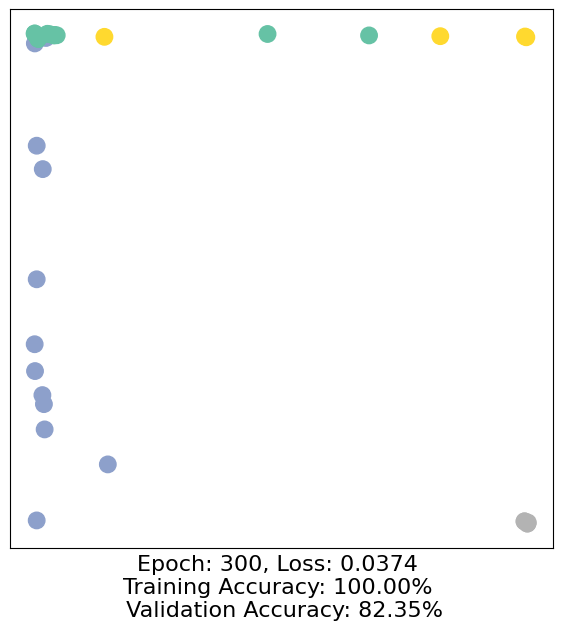

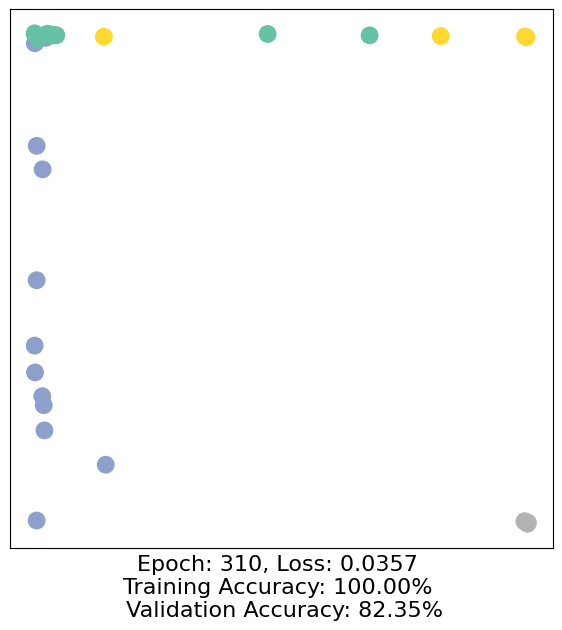

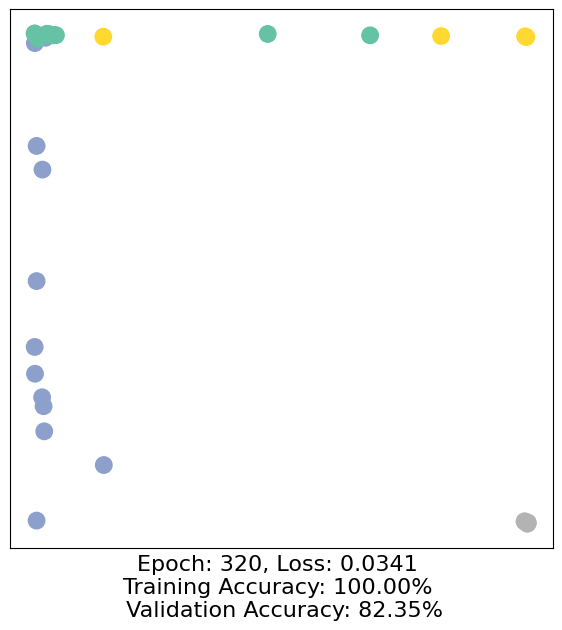

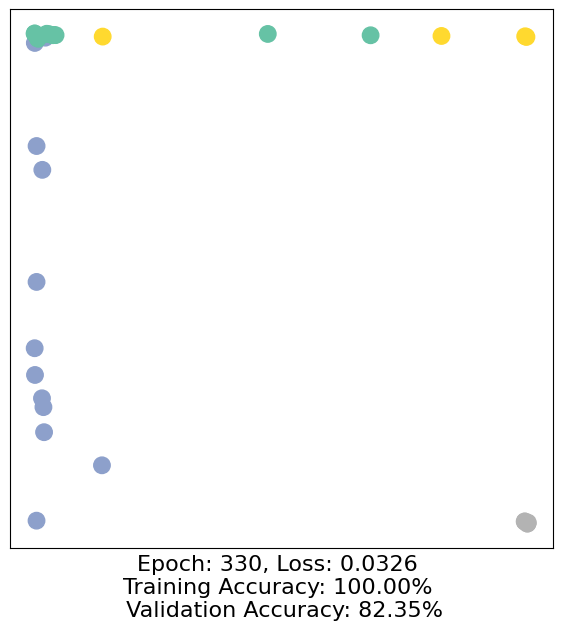

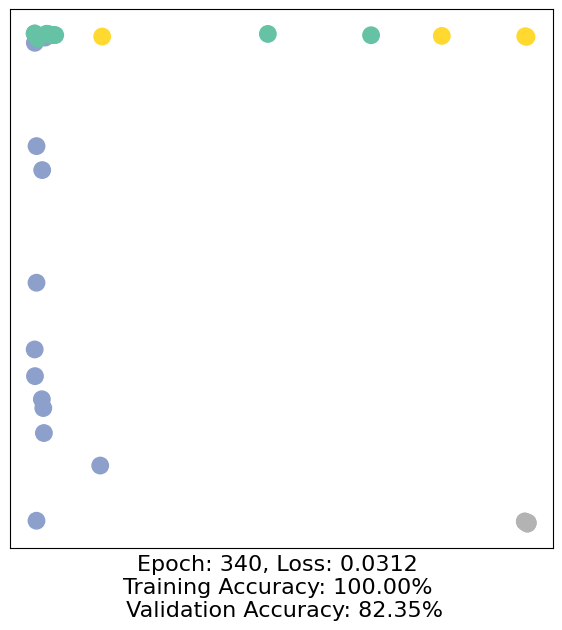

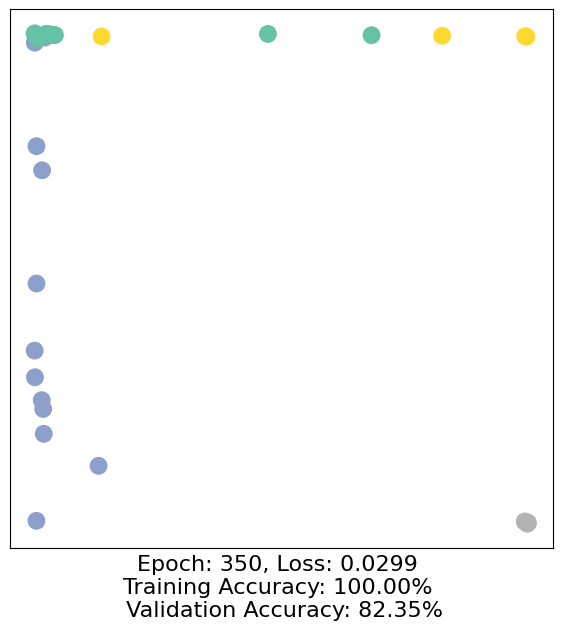

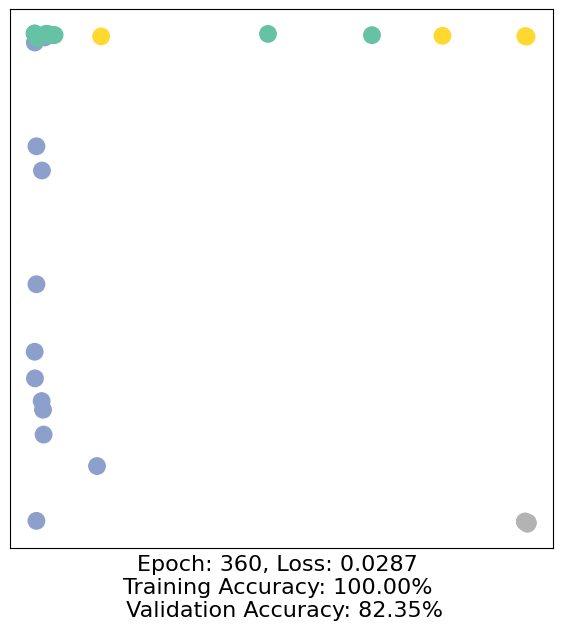

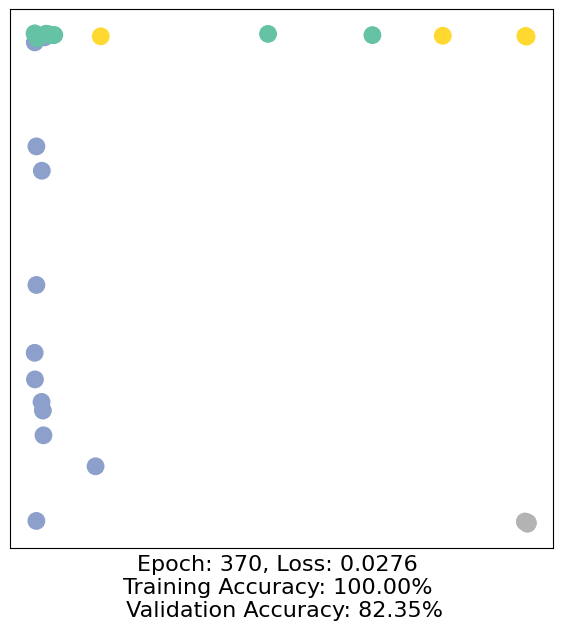

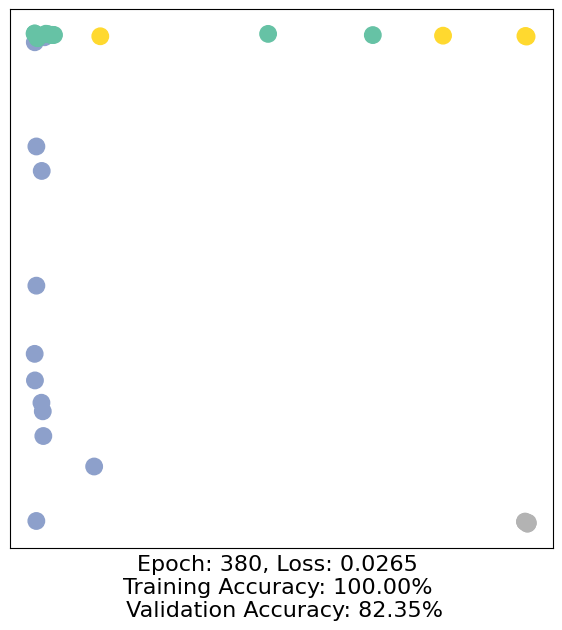

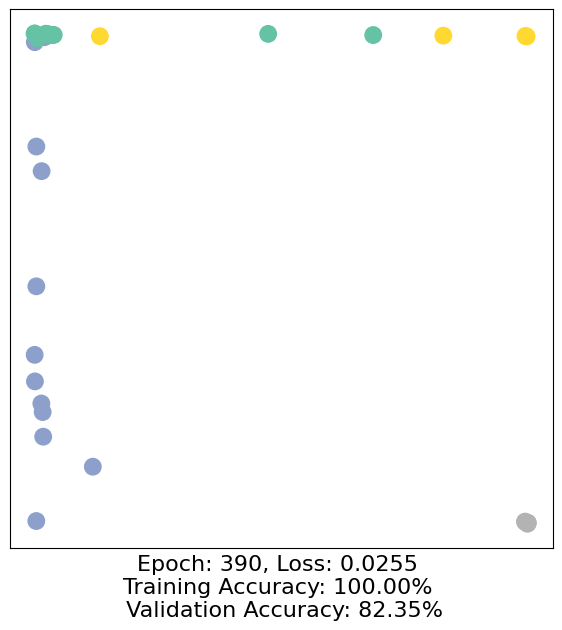

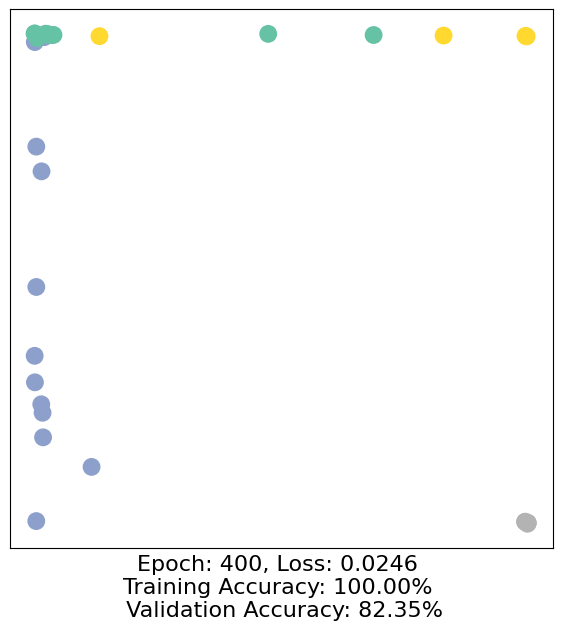

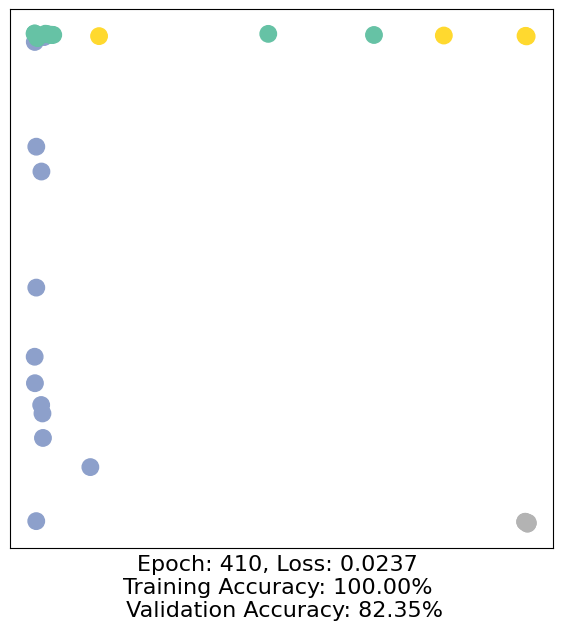

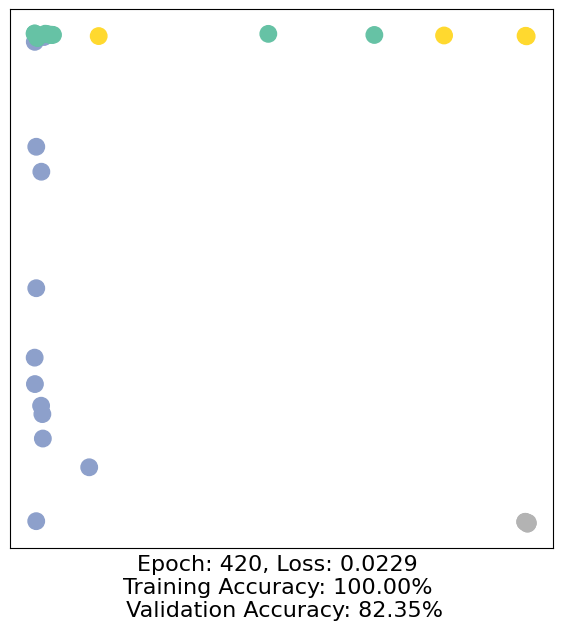

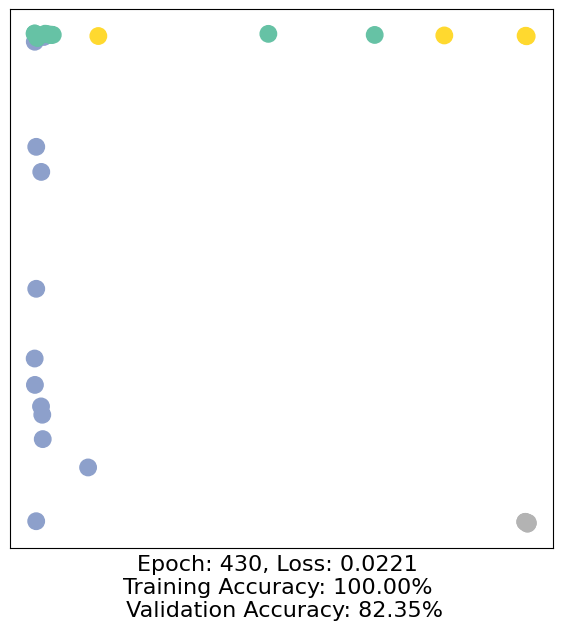

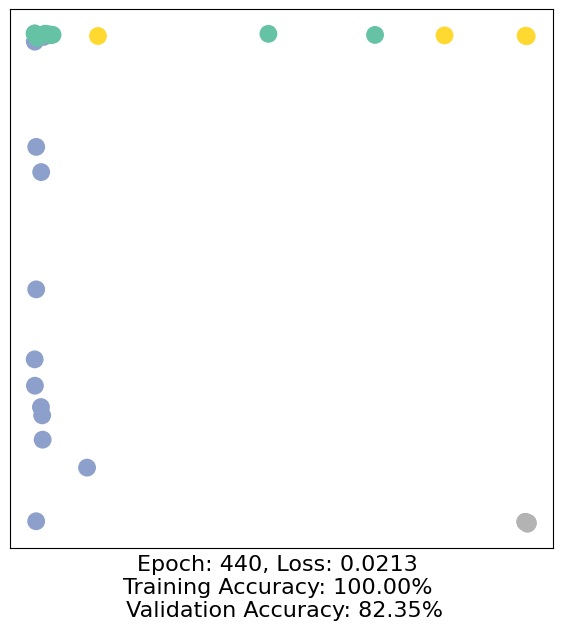

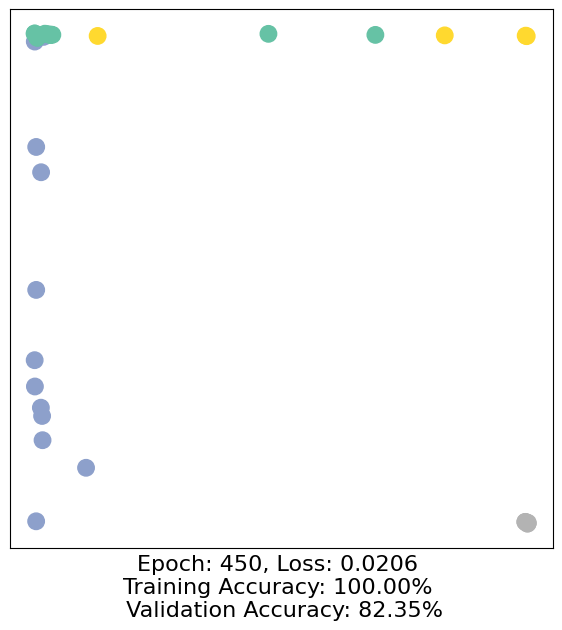

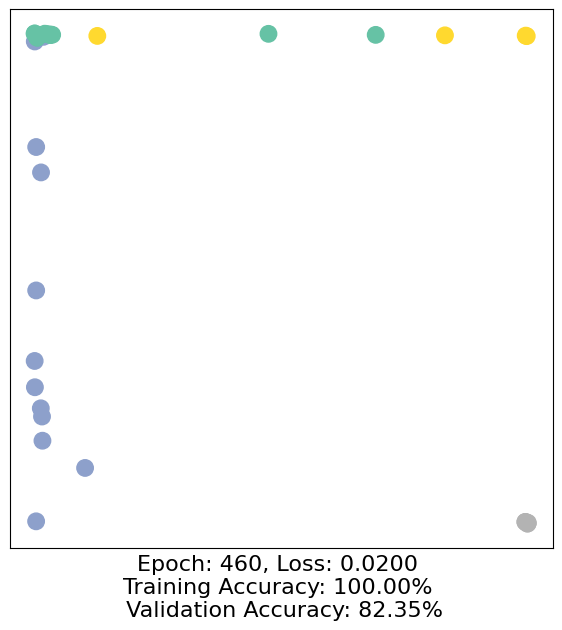

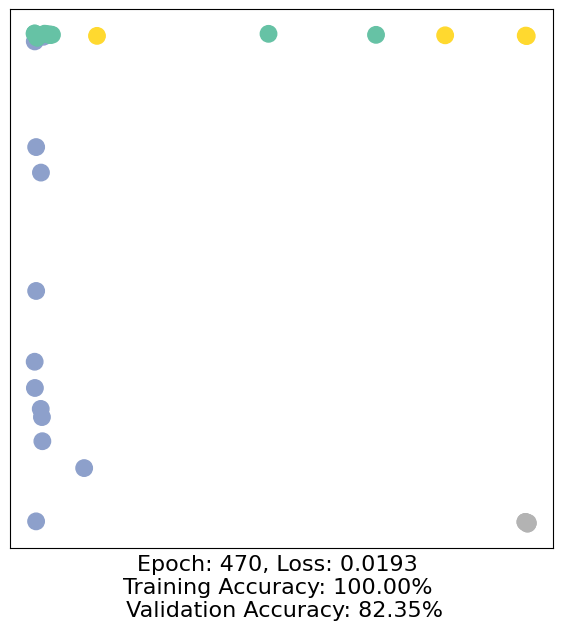

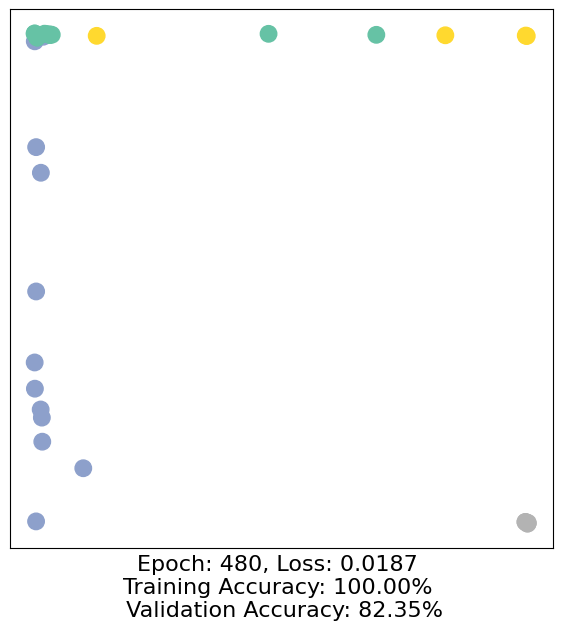

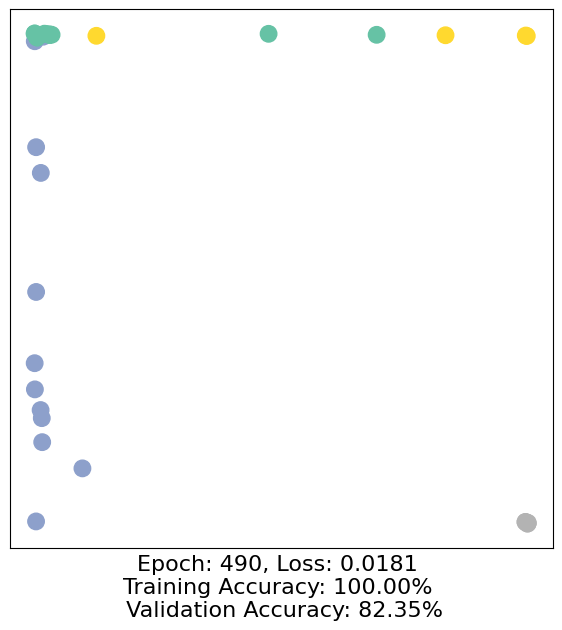

In [30]:
import time

model = GCN()
criterion = torch.nn.CrossEntropyLoss()  # Define o critério de perda.
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)  # Define o otimizador.

def train(data):
    optimizer.zero_grad()  # Limpa os gradientes.
    out, h = model(data.x, data.edge_index)  # Executa uma única passagem forward.
    loss = criterion(out[data.train_mask], data.y[data.train_mask])  # Calcula a perda apenas com base nos nodes de treino.
    loss.backward()  # Calcula os gradientes.
    optimizer.step()  # Atualiza os parâmetros com base nos gradientes.

    accuracy = {}
    # Calcula a acurácia de treino em nossos quatro exemplos
    predicted_classes = torch.argmax(out[data.train_mask], axis=1) # [0.6, 0.2, 0.7, 0.1] -> 2
    target_classes = data.y[data.train_mask]
    accuracy['train'] = torch.mean(
        torch.where(predicted_classes == target_classes, 1, 0).float())

    # Calcula a acurácia de validação em todo o grafo
    predicted_classes = torch.argmax(out, axis=1)
    target_classes = data.y
    accuracy['val'] = torch.mean(
        torch.where(predicted_classes == target_classes, 1, 0).float())

    return loss, h, accuracy

for epoch in range(500):
    loss, h, accuracy = train(data)
    # Visualiza os embeddings dos nós a cada 10 épocas
    if epoch % 10 == 0:
        visualize(h, color=data.y, epoch=epoch, loss=loss, accuracy=accuracy)
        time.sleep(0.3)

Com apenas 3 camadas, o modelo GCN (um dos mais simples possíveis) separou as comunidades e classificou a maioria dos nodes corretamente.